In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skdim
import os
# load .mat data
import scipy.io
from scipy.linalg import pinvh

import xarray as xr
import rioxarray
# add ../ to the path
import sys
sys.path.append('../')

import src.model as model

def save_to_geotiff(data, x_coord, y_coord, filename):
    # Create an xarray DataArray
    da = xr.DataArray(data, coords=[('y', y_coord), ('x', x_coord)])
    
    # Save to GeoTIFF using rioxarray
    da.rio.to_raster(filename)

%load_ext autoreload
%autoreload 2

data_path  = os.getenv('DATA_PATH')
param_path = os.getenv('PARAM_PATH')
folder = data_path
# ------------------------------------------------- LOAD SIMULATION DATA -------------------------------------------------
# get the DATA_PATH from the environment variable
X_filename           = 'trainingAll4D_Eb_sim_standardized.mat'
Y_filename           = 'trainingAll4D_Ns_sim_masked_standardized.mat'
H_filename           = 'H_gridded.mat'
Y_obs_filename       = "Ns_obs_gridded.mat"
mask_filename        = 'training_mask.mat' 
model_bound_filename = 'training_mask_domain_continuous.mat'
# also the mean and std of Eb for reverse standardization
Eb_mean_filename     = 'trainingAll_Eb_sim_mean.mat'
Eb_std_filename      = 'trainingAll_Eb_sim_std.mat'
# also the mean and std of Ns for standardization of observed data
Ns_mean_filename     = 'trainingAll_Ns_sim_mean_masked.mat'
Ns_std_filename      = 'trainingAll_Ns_sim_std_masked.mat'
# others
coord_filename       = "trainingAll_image_coord.mat"

# preprocessing parameter file: read the csv file
preprocess_param = pd.read_csv(param_path, index_col=0)
Eb_standardize_epsilon = preprocess_param['Eb_standardization_epsilon'].values[0]
Ns_standardize_epsilon = preprocess_param['Ns_standardization_epsilon'].values[0]
print("Eb_standardize_epsilon:", Eb_standardize_epsilon)
print("Ns_standardize_epsilon:", Ns_standardize_epsilon)


X_data           = scipy.io.loadmat(folder + X_filename)
Y_data           = scipy.io.loadmat(folder + Y_filename)
flight_mask_data = scipy.io.loadmat(folder + mask_filename) # this is the flightline mask
H_data           = scipy.io.loadmat(folder + H_filename)
model_bound_data = scipy.io.loadmat(folder + model_bound_filename) # this is model domain mask
coord_data       = scipy.io.loadmat(folder + coord_filename)
# standardization data for Eb
Eb_mean          = scipy.io.loadmat(folder + Eb_mean_filename)
Eb_std           = scipy.io.loadmat(folder + Eb_std_filename)

# load
Eb_standardized = X_data['Eb_standardized']
Ns_standardized = Y_data['Ns_standardized_masked']
# replace nan by 0
Eb_mean = np.nan_to_num(Eb_mean['Eb_mean'], nan=0.0)
Eb_std  = np.nan_to_num(Eb_std['Eb_std'], nan=0.0)

# -------------------------------------------------- LOAD OBSERVATION DATA --------------------------------------------------
Y_obs_data   = scipy.io.loadmat(folder + Y_obs_filename)
# standardization data for Ns
Ns_mean_data = scipy.io.loadmat(folder + Ns_mean_filename)
Ns_std_data  = scipy.io.loadmat(folder + Ns_std_filename)
Ns_mean = Ns_mean_data['Ns_mean_masked']
Ns_std = Ns_std_data['Ns_std_masked']  

Y_obs_data     = Y_obs_data['atten_rate_grid']
atten_rate_avg = Y_obs_data['atten_avg'][0][0]

# apply flightline masking to the standardization mean and std
flight_mask = flight_mask_data['mask']
flight_mask_bool = flight_mask.astype(bool)
Ns_mean_masked = Ns_mean.copy()
Ns_mean_masked[~flight_mask_bool] = 0 # set the mean to 0
Ns_std_masked = Ns_std.copy()
Ns_std_masked[~flight_mask_bool] = 1 # set the std to 1

# load model boundary
model_bound_data_ori = model_bound_data['in_domain_mask'].astype(bool)

x_coord = coord_data['training_coord'][0][0][0]
y_coord = coord_data['training_coord'][0][0][1]
extent = np.array([x_coord.min(), x_coord.max(), y_coord.max(), y_coord.min()])/1e3 # convert to km (left, right, bottom, top), imshow by default is inverted in y-axis

print('Shape of Eb_standardized:', Eb_standardized.shape)
print('Shape of Ns_standardized:', Ns_standardized.shape)
print('Shape of domain mask:', model_bound_data_ori.shape)
print('Shape of flight mask:', flight_mask_bool.shape)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Eb_standardize_epsilon: 1287.4819202075
Ns_standardize_epsilon: 0.262291780650704
Shape of Eb_standardized: (256, 256, 1, 1042)
Shape of Ns_standardized: (256, 256, 1, 1042)
Shape of domain mask: (256, 256)
Shape of flight mask: (256, 256)


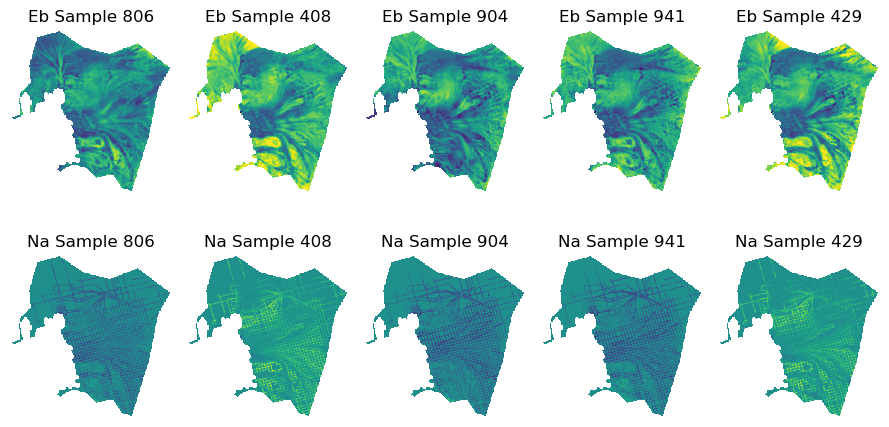

In [ ]:
# initialize the model object
md = model.model(extent=extent, coord=(x_coord, y_coord))
md.load_sim_data(Eb_standardized, Ns_standardized, 
                 domain_mask=model_bound_data_ori, 
                 flight_mask=flight_mask_bool, 
                 show_plot=True)

md.load_standardization_data(X_mean=Eb_mean, X_std=Eb_std,
                             Y_mean=Ns_mean_masked, Y_std=Ns_std_masked,
                             X_epsilon=Eb_standardize_epsilon, Y_epsilon=Ns_standardize_epsilon)

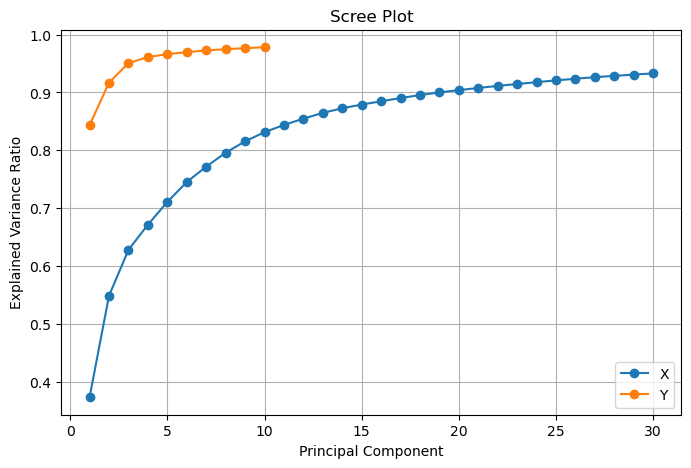

In [20]:
md.pca_scree(n_component_x=30, n_component_y=10)

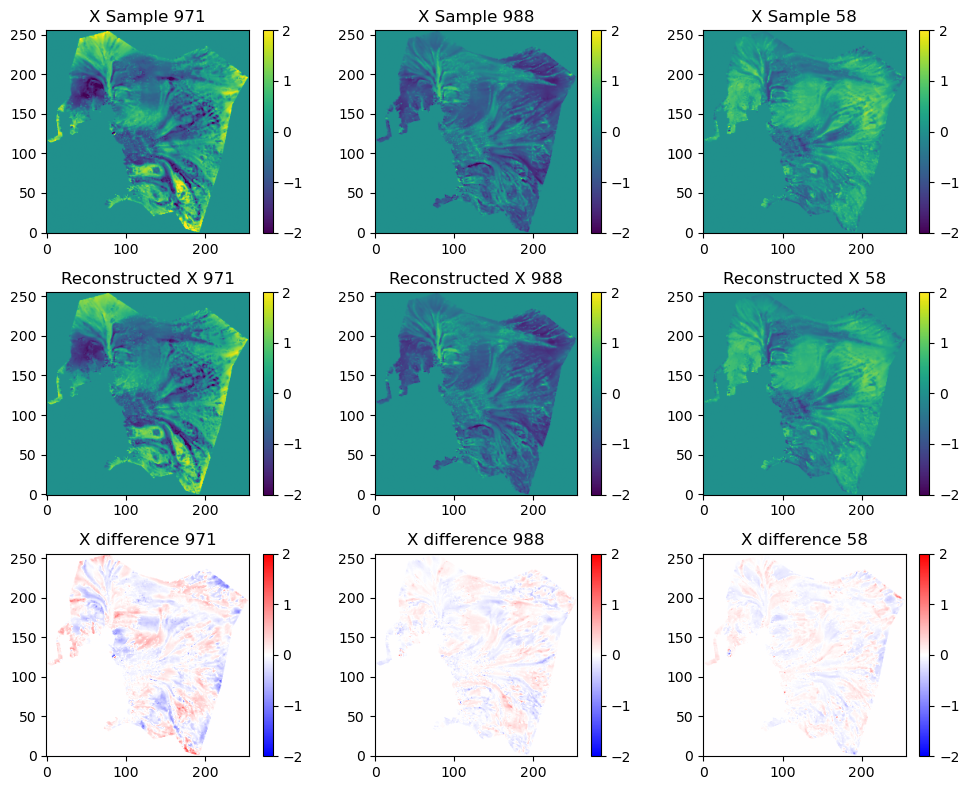

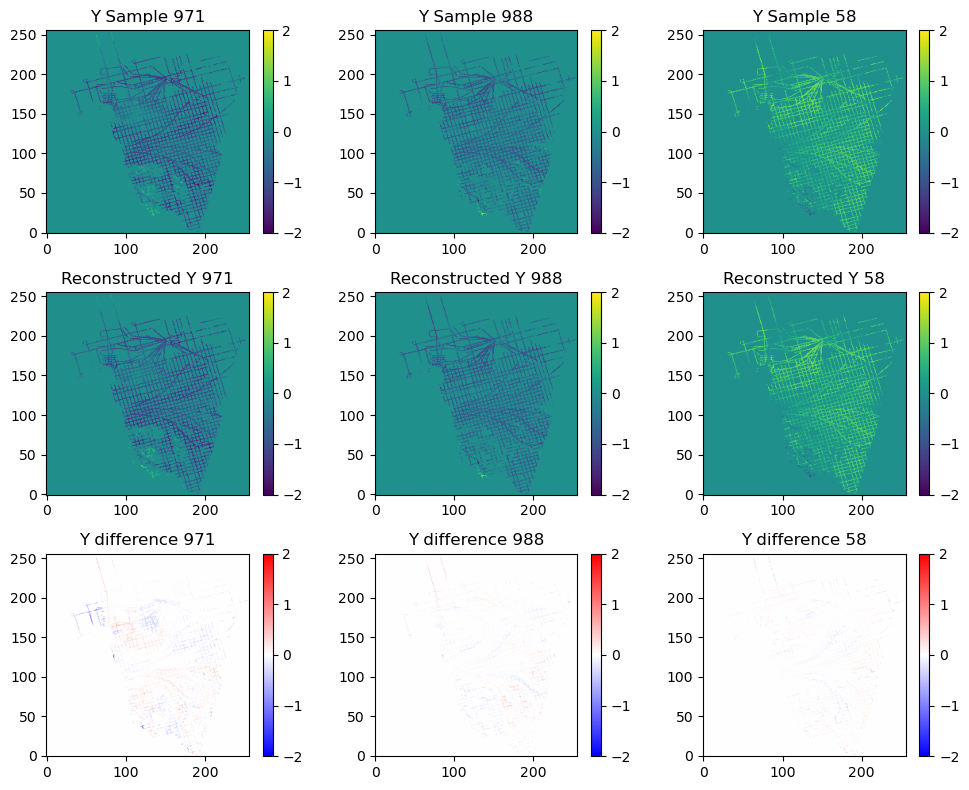

In [21]:
md.pca_recon_inspection(n_component_x=30, n_component_y=10)

In [ ]:
md.reduce(n_component_x=25, n_component_y=8)
md.data_split(train_ratio=0.8, validation_ratio=0.1, test_ratio=0.1)
md.train_gmm(n_components=25)
md.plot_gmm_samples(n_samples=3)

Shape of XY_train: (833, 33)
Shape of XY_validation: (104, 33)
Shape of XY_test: (105, 33)
GMM training completed in 0.08 seconds.


Using relaxation z-score standardization with epsilon = 0.262291780650704


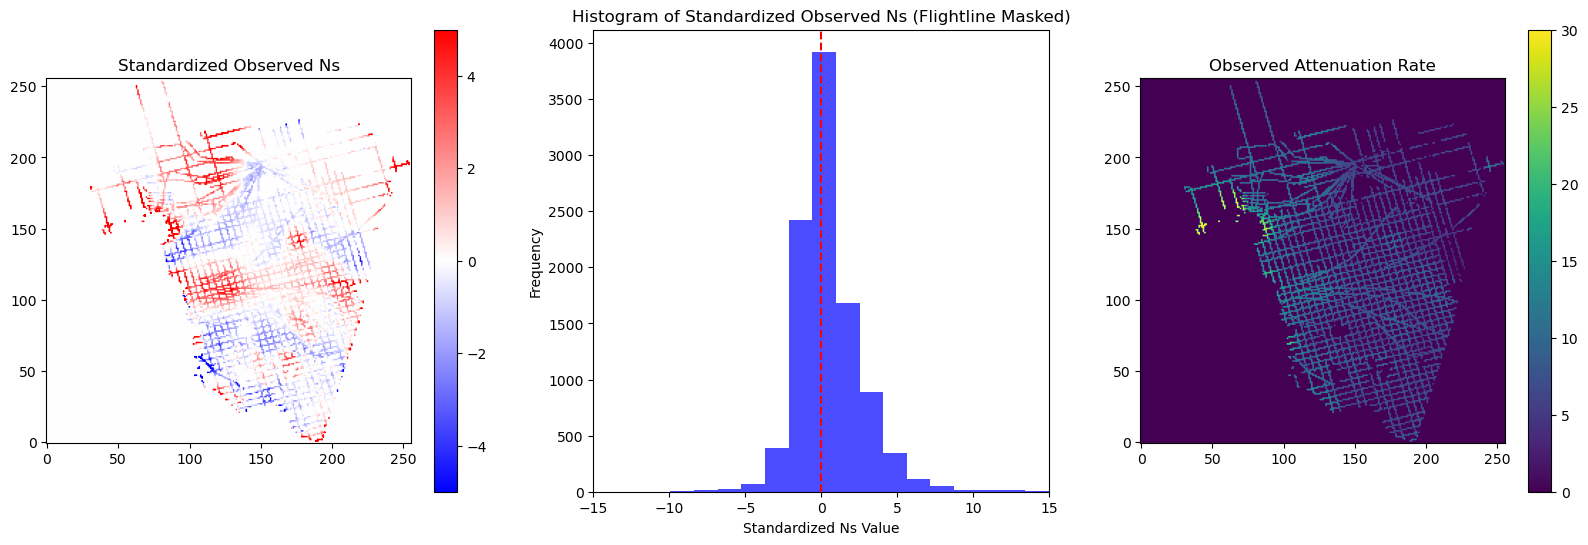

In [ ]:
md.load_obs_data(atten_rate_avg)